In [66]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import KFold
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

In [67]:
#train = pd.read_csv('/kaggle/input/datasets/chuahengli/electrochemical-dataset-cadde-1d/train.csv')
train = pd.read_csv('train.csv')
#display(train)
targets = pd.read_csv('train_targets.csv')
#display(target)


In [68]:
'''
Feature engineering
'''
def add_features(df):
    df = df.copy()
    
    # Safe interaction features (these are consistent train/test)
    df["current_x_voltage"] = df["Current(A)"] * df["Voltage(V)"]
    df["current_x_step"]    = df["Current(A)"] * df["Step_Index"]
    df["voltage_x_step"]    = df["Voltage(V)"] * df["Step_Index"]
    df["current_x_cycle"]   = df["Current(A)"] * df["Cycle_Index"]
    df["voltage_x_cycle"]   = df["Voltage(V)"] * df["Cycle_Index"]
    
    # Polynomial terms
    df["current_sq"]  = df["Current(A)"] ** 2
    df["voltage_sq"]  = df["Voltage(V)"] ** 2
    df["current_cu"]  = df["Current(A)"] ** 3
    df["voltage_cu"]  = df["Voltage(V)"] ** 3
    
    # dV/dt interactions
    df["dvdt_x_current"] = df["dV/dt(V/s)"] * df["Current(A)"]
    df["dvdt_x_voltage"] = df["dV/dt(V/s)"] * df["Voltage(V)"]
    
    # Capacity features (safe — both train/test have non-zero values)
    df["cap_ratio"]    = df["Charge_Capacity(Ah)"] / (df["Discharge_Capacity(Ah)"] + 1e-9)
    df["energy_ratio"] = df["Charge_Energy(Wh)"] / (df["Discharge_Energy(Wh)"] + 1e-9)
    
    
    return df
train = add_features(train)

In [69]:
''' 
Drop columns that are not important
'''
DROP_COLS = ["Date_Time", "Is_FC_Data", "AC_Impedance(Ohm)", "ACI_Phase_Angle(Deg)",
             "current_cu", "voltage_cu", "Discharge_Energy(Wh)", "Charge_Energy(Wh)",
             "voltage_sq", "Cycle_Index","Step_Index"]
train = train.drop(columns=DROP_COLS)

In [70]:
# Separate features and targets
train = train.merge(targets, on="id")
 
X = train.drop(columns=["id", "Target"])
y = train["Target"]
display(X)
print(f"Features used: {list(X.columns)}")
print(f"Total features: {X.shape[1]}")

,Data_Point,Test_Time(s),Step_Time(s),Current(A),Voltage(V),Charge_Capacity(Ah),Discharge_Capacity(Ah),dV/dt(V/s),Internal_Resistance(Ohm),current_x_voltage,current_x_step,voltage_x_step,current_x_cycle,voltage_x_cycle,current_sq,dvdt_x_current,dvdt_x_voltage,cap_ratio,energy_ratio
0,1,10.013550,9.949033,0.000000,3.270376,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.270376,0.000000,3.270376,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,20.028879,19.964361,0.000000,3.270376,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.270376,0.000000,3.270376,0.000000,0.000000,0.000000,0.000000,0.000000
2,3,30.044371,29.979853,0.000000,3.270538,0.000000,0.000000,0.000032,0.000000,0.000000,0.000000,3.270538,0.000000,3.270538,0.000000,0.000000,0.000106,0.000000,0.000000
3,4,40.059860,39.995342,0.000000,3.270376,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.270376,0.000000,3.270376,0.000000,0.000000,0.000000,0.000000,0.000000
4,5,50.059871,49.995354,0.000000,3.270376,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.270376,0.000000,3.270376,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,10996,403528.760272,30.015246,0.000000,4.099714,40.224297,40.283559,-0.000421,0.079157,0.000000,0.000000,12.299143,0.000000,143.490000,0.000000,-0.000000,-0.001726,0.998529,1.117055
99996,10997,403558.775505,60.030479,0.000000,4.089516,40.224297,40.283559,-0.000227,0.079157,0.000000,0.000000,12.268547,0.000000,143.133049,0.000000,-0.000000,-0.000927,0.998529,1.117055
99997,10998,403588.790781,90.045755,0.000000,4.083526,40.224297,40.283559,-0.000130,0.079157,0.000000,0.000000,12.250578,0.000000,142.923415,0.000000,-0.000000,-0.000529,0.998529,1.117055
99998,10999,403618.759277,120.014252,0.000000,4.079641,40.224297,40.283559,-0.000065,0.079157,0.000000,0.000000,12.238923,0.000000,142.787430,0.000000,-0.000000,-0.000264,0.998529,1.117055


Features used: ['Data_Point', 'Test_Time(s)', 'Step_Time(s)', 'Current(A)', 'Voltage(V)', 'Charge_Capacity(Ah)', 'Discharge_Capacity(Ah)', 'dV/dt(V/s)', 'Internal_Resistance(Ohm)', 'current_x_voltage', 'current_x_step', 'voltage_x_step', 'current_x_cycle', 'voltage_x_cycle', 'current_sq', 'dvdt_x_current', 'dvdt_x_voltage', 'cap_ratio', 'energy_ratio']
Total features: 19


In [71]:
# Cross-validation and train final model

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=50,
        random_state=42
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_preds[val_idx] = model.predict(X_val)
    models.append(model)
    print(f"Fold {fold+1} R²: {r2_score(y_val, oof_preds[val_idx]):.4f}")

print(f"OOF R²: {r2_score(y, oof_preds):.4f}")

Fold 1 R²: 0.9830
Fold 2 R²: 0.9835
Fold 3 R²: 0.9830
Fold 4 R²: 0.9832
Fold 5 R²: 0.9831
OOF R²: 0.9831


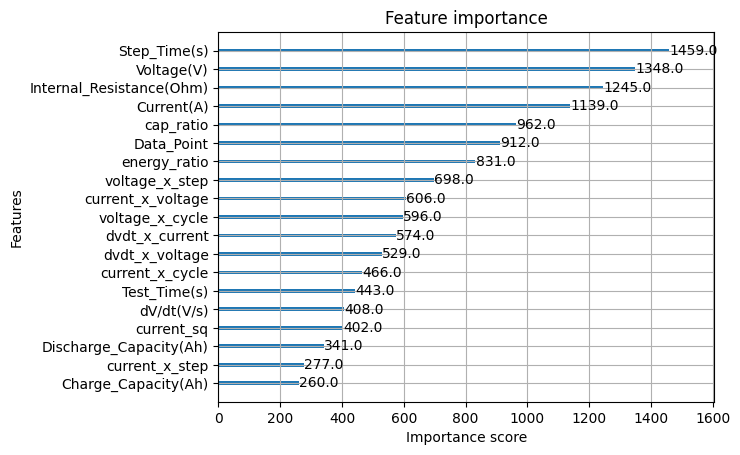

In [72]:
model = models[1]
xgb.plot_importance(model)
plt.show()

In [73]:
# Create submission
#test = pd.read_csv('/kaggle/input/datasets/chuahengli/electrochemical-dataset-cadde-1d/test.csv')
test = pd.read_csv('test.csv')
test = add_features(test)
test = test.drop(columns=DROP_COLS)
X_test = test.drop(columns=["id"])

test_preds = model.predict(X_test)
submission = pd.DataFrame({"id": test["id"], "pred": test_preds})
submission.to_csv("submission.csv", index=False)